# Video Inference with CNN Baseline

This notebook applies the trained CNN baseline model to classify parking spaces in video frames.

Features:
- Load trained CNN model from checkpoint
- Define parking slot regions (ROIs) manually
- Process video frames and classify each parking slot
- Generate annotated output video with colored boxes and labels


## 1. Imports and Configuration


In [ ]:
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
MODEL_PATH = CHECKPOINT_DIR / "best_model.pt"

# Video paths
VIDEO_DIR = BASE_DIR / "data" / "raw" / "UFPARK - Dataset" / "morning_samples_anonimized"
OUTPUT_DIR = BASE_DIR / "data" / "processed" / "video_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("MODEL_PATH exists:", MODEL_PATH.exists())
print("VIDEO_DIR exists:", VIDEO_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

# Model configuration (must match training)
IMG_SIZE = 128
class_names = ["free", "not_free", "partial"]  # Order from ImageFolder during training
num_classes = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: c:\Harosha\George Brown\DL2\parking-vision
MODEL_PATH exists: True
VIDEO_DIR exists: True
OUTPUT_DIR: c:\Harosha\George Brown\DL2\parking-vision\data\processed\video_output
Using device: cpu


## 2. Model Definition and Loading


In [ ]:
class SimpleParkingCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        conv_output_size = 64 * (IMG_SIZE // 8) * (IMG_SIZE // 8)

        self.fc1 = nn.Linear(conv_output_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128->64
        x = self.pool(F.relu(self.conv2(x)))  # 64->32
        x = self.pool(F.relu(self.conv3(x)))  # 32->16
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Load model
model = SimpleParkingCNN(num_classes=num_classes).to(device)

if MODEL_PATH.exists():
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded model from checkpoint (epoch {checkpoint.get('epoch', 'unknown')})")
    else:
        # Old format - direct state dict
        model.load_state_dict(checkpoint)
        print("Loaded model from checkpoint (old format)")
    model.eval()
    print("Model loaded successfully!")
else:
    print(f"WARNING: Model checkpoint not found at {MODEL_PATH}")
    print("Please train the model first using notebook 02_cnn_baseline.ipynb")


Loaded model from checkpoint (epoch 6)
Model loaded successfully!


C:\Users\haros\AppData\Local\Temp\ipykernel_31760\513692987.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)


## 3. Define Transforms


In [ ]:
# Same normalization as during training
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

print("Transforms defined (matching training configuration)")


Transforms defined (matching training configuration)


## 4. Helper Functions


In [ ]:
def classify_patch(bgr_patch: np.ndarray) -> tuple:
    """
    Takes a BGR patch from OpenCV, returns (predicted_class, confidence).
    
    Args:
        bgr_patch: BGR image patch (numpy array)
    
    Returns:
        tuple: (class_name, confidence_score)
    """
    if bgr_patch.size == 0:
        return ("unknown", 0.0)
    
    # Convert BGR -> RGB
    rgb = cv2.cvtColor(bgr_patch, cv2.COLOR_BGR2RGB)
    tensor = transform(rgb).unsqueeze(0).to(device)  # (1, 3, H, W)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    return (class_names[pred_idx], confidence)

# Color mapping for visualization
COLOR_MAP = {
    "free": (0, 255, 0),        # green (BGR)
    "not_free": (0, 0, 255),    # red (BGR)
    "partial": (0, 255, 255),   # yellow (BGR)
    "unknown": (128, 128, 128), # gray
}


## 5. List Available Videos


In [ ]:
# List all video files
video_files = list(VIDEO_DIR.glob("*.avi")) + list(VIDEO_DIR.glob("*.mp4")) + list(VIDEO_DIR.glob("*.mov"))
video_files.sort()

print(f"Found {len(video_files)} video files:")
for i, video_path in enumerate(video_files[:10]):  # Show first 10
    print(f"  {i+1}. {video_path.name}")
if len(video_files) > 10:
    print(f"  ... and {len(video_files) - 10} more")

# Select a video to process (change index as needed)
SELECTED_VIDEO_INDEX = 0  # Change this to select a different video
if video_files:
    VIDEO_INPUT = video_files[SELECTED_VIDEO_INDEX]
    VIDEO_OUTPUT = OUTPUT_DIR / f"{VIDEO_INPUT.stem}_cnn_annotated.mp4"
    print(f"\nSelected video: {VIDEO_INPUT.name}")
    print(f"Output will be saved to: {VIDEO_OUTPUT.name}")
else:
    print("\nNo video files found!")
    VIDEO_INPUT = None
    VIDEO_OUTPUT = None


Found 55 video files:
  1. 2020-03-19-08-00-00.scene_0000TESTE_BB_write.avi
  2. 2020-03-19-08-00-00.scene_0002_BB_write.avi
  3. 2020-03-19-08-00-00.scene_0003_BB_write.avi
  4. 2020-03-19-08-00-00.scene_0004_BB_write.avi
  5. 2020-03-19-08-00-00.scene_0005_BB_write.avi
  6. 2020-03-19-08-00-00.scene_0006_BB_write.avi
  7. 2020-03-19-08-00-00.scene_0008_BB_write.avi
  8. 2020-03-19-08-00-00.scene_0009_BB_write.avi
  9. 2020-03-19-08-00-00.scene_0010_BB_write.avi
  10. 2020-03-19-08-00-00.scene_0011_BB_write.avi
  ... and 45 more

Selected video: 2020-03-19-08-00-00.scene_0000TESTE_BB_write.avi
Output will be saved to: 2020-03-19-08-00-00.scene_0000TESTE_BB_write_cnn_annotated.mp4


## 6. Visualize First Frame to Define Parking Slots


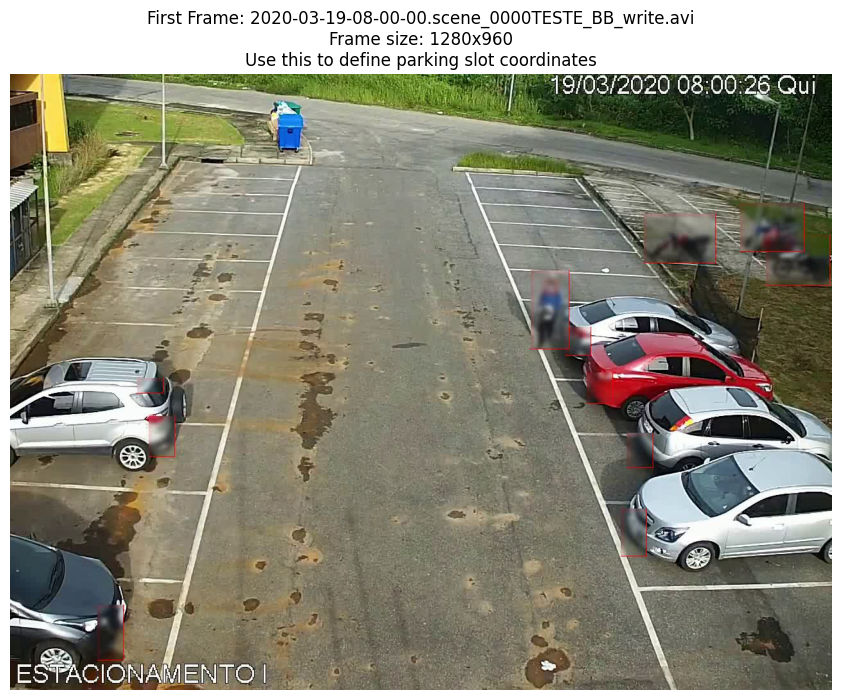

Frame dimensions: 1280 x 960

Use the frame above to identify parking slot regions.
Define SLOTS list with coordinates (x1, y1, x2, y2) for each parking space.


In [ ]:
# Load and display first frame to help define parking slots
if VIDEO_INPUT and VIDEO_INPUT.exists():
    cap = cv2.VideoCapture(str(VIDEO_INPUT))
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        # Convert BGR to RGB for matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        height, width = frame.shape[:2]
        
        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)
        plt.title(f"First Frame: {VIDEO_INPUT.name}\nFrame size: {width}x{height}\nUse this to define parking slot coordinates")
        plt.axis("off")
        plt.show()
        
        print(f"Frame dimensions: {width} x {height}")
        print("\nUse the frame above to identify parking slot regions.")
        print("Define SLOTS list with coordinates (x1, y1, x2, y2) for each parking space.")
    else:
        print("Could not read first frame from video")
else:
    print("Video file not found. Please check VIDEO_INPUT path.")


## 7. Define Parking Slot Regions (ROIs)

**Instructions:**
1. Use the frame visualization above to identify parking spaces
2. Define coordinates for each parking slot as rectangles (x1, y1, x2, y2)
3. You can use OpenCV's mouse callback or manually estimate coordinates
4. Update the SLOTS list below with your parking space coordinates


In [ ]:
# Example/placeholder coordinates - YOU MUST TUNE THESE FOR YOUR VIDEO
# Format: {"id": "slot_id", "x1": left, "y1": top, "x2": right, "y2": bottom}
# Coordinates are in pixels: (x1, y1) is top-left, (x2, y2) is bottom-right

SLOTS = [
    # Example slots - replace with actual coordinates from your video
    # {"id": "S1", "x1": 100, "y1": 200, "x2": 200, "y2": 320},
    # {"id": "S2", "x1": 220, "y1": 200, "x2": 320, "y2": 320},
    # {"id": "S3", "x1": 340, "y1": 200, "x2": 440, "y2": 320},
    # Add more slots as needed...
]

print(f"Defined {len(SLOTS)} parking slots")
if SLOTS:
    print("Slot coordinates:")
    for slot in SLOTS:
        print(f"  {slot['id']}: ({slot['x1']}, {slot['y1']}) to ({slot['x2']}, {slot['y2']})")
else:
    print("WARNING: No parking slots defined! Please add slot coordinates above.")


Defined 0 parking slots


### 7.1 Interactive Slot Definition Tool (Optional)

Run this cell to interactively define parking slots by clicking on the frame.


In [ ]:
# Interactive slot definition using mouse clicks
# Uncomment and run this cell to interactively define slots


# Global variables for mouse callback
drawing = False
start_point = None
current_slots = []
slot_counter = 1

def mouse_callback(event, x, y, flags, param):
    global drawing, start_point, current_slots, slot_counter, frame_copy
    
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        start_point = (x, y)
    
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            frame_temp = frame_copy.copy()
            cv2.rectangle(frame_temp, start_point, (x, y), (0, 255, 0), 2)
            cv2.imshow('Define Parking Slots', frame_temp)
    
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        end_point = (x, y)
        x1, y1 = min(start_point[0], end_point[0]), min(start_point[1], end_point[1])
        x2, y2 = max(start_point[0], end_point[0]), max(start_point[1], end_point[1])
        
        if abs(x2 - x1) > 10 and abs(y2 - y1) > 10:  # Minimum size
            slot_id = f"S{slot_counter}"
            current_slots.append({"id": slot_id, "x1": x1, "y1": y1, "x2": x2, "y2": y2})
            cv2.rectangle(frame_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame_copy, slot_id, (x1, y1 - 5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.imshow('Define Parking Slots', frame_copy)
            slot_counter += 1
            print(f"Added slot {slot_id}: ({x1}, {y1}) to ({x2}, {y2})")

if VIDEO_INPUT and VIDEO_INPUT.exists():
    cap = cv2.VideoCapture(str(VIDEO_INPUT))
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        frame_copy = frame.copy()
        cv2.namedWindow('Define Parking Slots')
        cv2.setMouseCallback('Define Parking Slots', mouse_callback)
        
        print("Instructions:")
        print("1. Click and drag to draw a rectangle around a parking space")
        print("2. Press 'q' to quit and save slots")
        print("3. Press 'r' to reset all slots")
        
        while True:
            cv2.imshow('Define Parking Slots', frame_copy)
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break
            elif key == ord('r'):
                current_slots = []
                slot_counter = 1
                frame_copy = frame.copy()
                print("Reset all slots")
        
        cv2.destroyAllWindows()
        
        if current_slots:
            SLOTS = current_slots
            print(f"\nDefined {len(SLOTS)} slots:")
            for slot in SLOTS:
                print(f"  {slot}")
        else:
            print("No slots defined")


print("Interactive slot definition is disabled. Uncomment the code above to enable.")
print("Alternatively, manually define SLOTS in the previous cell.")


Instructions:
1. Click and drag to draw a rectangle around a parking space
2. Press 'q' to quit and save slots
3. Press 'r' to reset all slots
Added slot S1: (975, 585) to (1276, 758)
Added slot S2: (993, 484) to (1257, 607)
Added slot S3: (878, 409) to (1200, 520)
Added slot S4: (856, 341) to (1139, 441)
Added slot S5: (808, 295) to (1032, 344)
Added slot S6: (795, 245) to (1008, 314)
Added slot S7: (782, 213) to (980, 275)
Added slot S8: (770, 182) to (942, 233)
Added slot S9: (741, 147) to (916, 201)
Added slot S10: (727, 113) to (900, 176)
Added slot S11: (5, 605) to (281, 757)
Added slot S12: (7, 465) to (310, 649)
Added slot S13: (39, 421) to (343, 530)
Added slot S14: (74, 364) to (363, 445)
Added slot S15: (101, 305) to (384, 387)
Added slot S16: (132, 269) to (393, 334)
Added slot S17: (168, 234) to (407, 290)
Added slot S18: (218, 193) to (420, 252)
Added slot S19: (231, 154) to (428, 219)
Added slot S20: (249, 141) to (437, 188)
Added slot S21: (269, 114) to (448, 166)

Defi

Instructions:
1. Click and drag to draw a rectangle around a parking space
2. Press 'q' to quit and save slots
3. Press 'r' to reset all slots
Added slot S1: (975, 585) to (1276, 758)
Added slot S2: (993, 484) to (1257, 607)
Added slot S3: (878, 409) to (1200, 520)
Added slot S4: (856, 341) to (1139, 441)
Added slot S5: (808, 295) to (1032, 344)
Added slot S6: (795, 245) to (1008, 314)
Added slot S7: (782, 213) to (980, 275)
Added slot S8: (770, 182) to (942, 233)
Added slot S9: (741, 147) to (916, 201)
Added slot S10: (727, 113) to (900, 176)
Added slot S11: (5, 605) to (281, 757)
Added slot S12: (7, 465) to (310, 649)
Added slot S13: (39, 421) to (343, 530)
Added slot S14: (74, 364) to (363, 445)
Added slot S15: (101, 305) to (384, 387)
Added slot S16: (132, 269) to (393, 334)
Added slot S17: (168, 234) to (407, 290)
Added slot S18: (218, 193) to (420, 252)
Added slot S19: (231, 154) to (428, 219)
Added slot S20: (249, 141) to (437, 188)
Added slot S21: (269, 114) to (448, 166)

Defined 21 slots:
  {'id': 'S1', 'x1': 975, 'y1': 585, 'x2': 1276, 'y2': 758}
  {'id': 'S2', 'x1': 993, 'y1': 484, 'x2': 1257, 'y2': 607}
  {'id': 'S3', 'x1': 878, 'y1': 409, 'x2': 1200, 'y2': 520}
  {'id': 'S4', 'x1': 856, 'y1': 341, 'x2': 1139, 'y2': 441}
  {'id': 'S5', 'x1': 808, 'y1': 295, 'x2': 1032, 'y2': 344}
  {'id': 'S6', 'x1': 795, 'y1': 245, 'x2': 1008, 'y2': 314}
  {'id': 'S7', 'x1': 782, 'y1': 213, 'x2': 980, 'y2': 275}
  {'id': 'S8', 'x1': 770, 'y1': 182, 'x2': 942, 'y2': 233}
  {'id': 'S9', 'x1': 741, 'y1': 147, 'x2': 916, 'y2': 201}
  {'id': 'S10', 'x1': 727, 'y1': 113, 'x2': 900, 'y2': 176}
  {'id': 'S11', 'x1': 5, 'y1': 605, 'x2': 281, 'y2': 757}
  {'id': 'S12', 'x1': 7, 'y1': 465, 'x2': 310, 'y2': 649}
  {'id': 'S13', 'x1': 39, 'y1': 421, 'x2': 343, 'y2': 530}
  {'id': 'S14', 'x1': 74, 'y1': 364, 'x2': 363, 'y2': 445}
  {'id': 'S15', 'x1': 101, 'y1': 305, 'x2': 384, 'y2': 387}
  {'id': 'S16', 'x1': 132, 'y1': 269, 'x2': 393, 'y2': 334}
  {'id': 'S17', 'x1': 168, 'y1': 234, 'x2': 407, 'y2': 290}
  {'id': 'S18', 'x1': 218, 'y1': 193, 'x2': 420, 'y2': 252}
  {'id': 'S19', 'x1': 231, 'y1': 154, 'x2': 428, 'y2': 219}
  {'id': 'S20', 'x1': 249, 'y1': 141, 'x2': 437, 'y2': 188}
  {'id': 'S21', 'x1': 269, 'y1': 114, 'x2': 448, 'y2': 166}
Interactive slot definition is disabled. Uncomment the code above to enable.
Alternatively, manually define SLOTS in the previous cell.

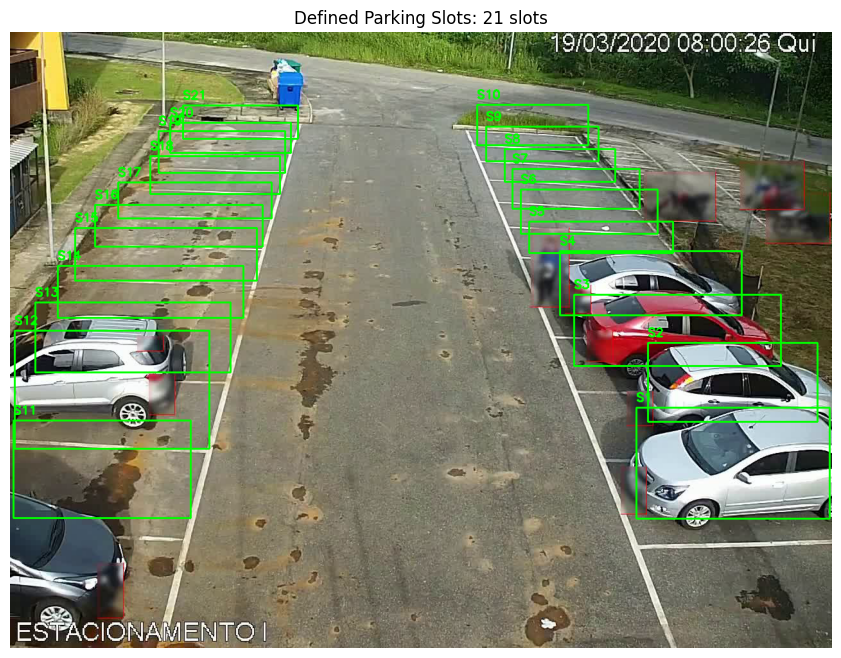

Visualized 21 parking slots on the frame


In [ ]:
# Visualize the defined slots on the first frame
if VIDEO_INPUT and VIDEO_INPUT.exists() and SLOTS:
    cap = cv2.VideoCapture(str(VIDEO_INPUT))
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        frame_vis = frame.copy()
        
        for slot in SLOTS:
            x1, y1, x2, y2 = slot["x1"], slot["y1"], slot["x2"], slot["y2"]
            cv2.rectangle(frame_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame_vis, slot["id"], (x1, max(0, y1 - 10)),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        frame_rgb = cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)
        plt.title(f"Defined Parking Slots: {len(SLOTS)} slots")
        plt.axis("off")
        plt.show()
        
        print(f"Visualized {len(SLOTS)} parking slots on the frame")
    else:
        print("Could not read frame for visualization")
elif not SLOTS:
    print("No slots defined. Please define SLOTS in the previous cell.")
else:
    print("Video file not found")


## 8. Video Processing Pipeline


In [ ]:
if not VIDEO_INPUT or not VIDEO_INPUT.exists():
    print("ERROR: Video file not found. Please check VIDEO_INPUT path.")
elif not SLOTS:
    print("ERROR: No parking slots defined. Please define SLOTS before processing.")
elif not MODEL_PATH.exists():
    print("ERROR: Model checkpoint not found. Please train the model first.")
else:
    print("Starting video processing...")
    print(f"Input: {VIDEO_INPUT.name}")
    print(f"Output: {VIDEO_OUTPUT.name}")
    print(f"Processing {len(SLOTS)} parking slots per frame")
    
    # Open video
    cap = cv2.VideoCapture(str(VIDEO_INPUT))
    if not cap.isOpened():
        print(f"ERROR: Could not open video: {VIDEO_INPUT}")
    else:
        # Get video properties
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        print(f"Video properties: {width}x{height} @ {fps:.2f} FPS, {total_frames} frames")
        
        # Define VideoWriter for output
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(str(VIDEO_OUTPUT), fourcc, fps, (width, height))
        
        frame_idx = 0
        
        # Process frames
        with tqdm(total=total_frames, desc="Processing frames") as pbar:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                frame_idx += 1
                
                # Process each parking slot
                for slot in SLOTS:
                    x1, y1, x2, y2 = slot["x1"], slot["y1"], slot["x2"], slot["y2"]
                    
                    # Safety clipping to frame bounds
                    x1 = max(0, min(x1, width - 1))
                    x2 = max(0, min(x2, width - 1))
                    y1 = max(0, min(y1, height - 1))
                    y2 = max(0, min(y2, height - 1))
                    
                    if x2 <= x1 or y2 <= y1:
                        continue
                    
                    # Extract patch
                    patch = frame[y1:y2, x1:x2]
                    if patch.size == 0:
                        continue
                    
                    # Classify patch
                    label, confidence = classify_patch(patch)
                    color = COLOR_MAP.get(label, (255, 255, 255))
                    
                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    
                    # Draw text (ID + label + confidence)
                    text = f"{slot['id']}: {label} ({confidence:.2f})"
                    cv2.putText(frame, text, (x1, max(0, y1 - 10)),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)
                
                # Write frame
                out.write(frame)
                pbar.update(1)
        
        cap.release()
        out.release()
        
        print(f"\nProcessing complete!")
        print(f"Processed {frame_idx} frames")
        print(f"Output saved to: {VIDEO_OUTPUT}")
        print(f"File size: {VIDEO_OUTPUT.stat().st_size / (1024*1024):.2f} MB")


Starting video processing...
Input: 2020-03-19-08-00-00.scene_0000TESTE_BB_write.avi
Output: 2020-03-19-08-00-00.scene_0000TESTE_BB_write_cnn_annotated.mp4
Processing 21 parking slots per frame
Video properties: 1280x960 @ 30.00 FPS, 599 frames


Processing frames:   0%|          | 0/599 [00:00<?, ?it/s]

Processing frames: 100%|██████████| 599/599 [02:10<00:00,  4.60it/s]



Processing complete!
Processed 599 frames
Output saved to: c:\Harosha\George Brown\DL2\parking-vision\data\processed\video_output\2020-03-19-08-00-00.scene_0000TESTE_BB_write_cnn_annotated.mp4
File size: 29.98 MB


## 9. Preview Output Video (First Frame)

Preview the first annotated frame to verify the results.


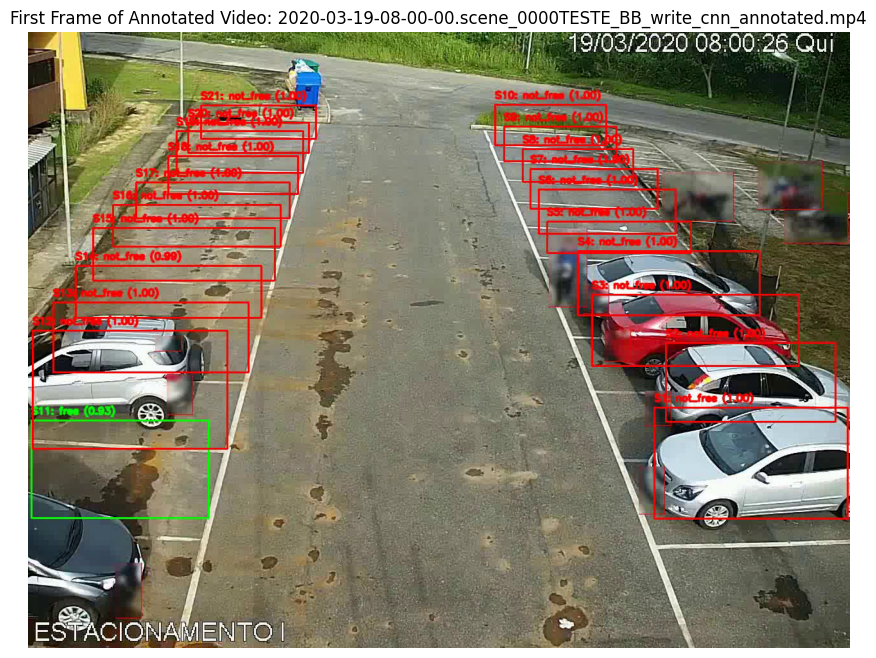

Preview of annotated video (first frame)
Colors: Green=free, Red=not_free, Yellow=partial


In [ ]:
# Preview first frame of output video
if VIDEO_OUTPUT and VIDEO_OUTPUT.exists():
    cap = cv2.VideoCapture(str(VIDEO_OUTPUT))
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)
        plt.title(f"First Frame of Annotated Video: {VIDEO_OUTPUT.name}")
        plt.axis("off")
        plt.show()
        
        print("Preview of annotated video (first frame)")
        print("Colors: Green=free, Red=not_free, Yellow=partial")
    else:
        print("Could not read output video")
else:
    print("Output video not found. Please run the processing cell first.")


## 10. Process Multiple Videos (Batch Processing)

Process all videos in the dataset with the same slot definitions.


In [18]:
# Batch process all videos (optional)
# Set PROCESS_ALL_VIDEOS = True to process all videos, False to skip
PROCESS_ALL_VIDEOS = False

if PROCESS_ALL_VIDEOS and SLOTS and MODEL_PATH.exists():
    video_files = list(VIDEO_DIR.glob("*.avi")) + list(VIDEO_DIR.glob("*.mp4"))
    video_files.sort()
    
    print(f"Processing {len(video_files)} videos...")
    
    for video_idx, video_input in enumerate(video_files):
        video_output = OUTPUT_DIR / f"{video_input.stem}_cnn_annotated.mp4"
        
        print(f"\n[{video_idx+1}/{len(video_files)}] Processing: {video_input.name}")
        
        cap = cv2.VideoCapture(str(video_input))
        if not cap.isOpened():
            print(f"  ERROR: Could not open {video_input.name}")
            continue
        
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(str(video_output), fourcc, fps, (width, height))
        
        frame_count = 0
        with tqdm(total=total_frames, desc=f"  {video_input.name[:30]}") as pbar:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                for slot in SLOTS:
                    x1, y1, x2, y2 = slot["x1"], slot["y1"], slot["x2"], slot["y2"]
                    x1 = max(0, min(x1, width - 1))
                    x2 = max(0, min(x2, width - 1))
                    y1 = max(0, min(y1, height - 1))
                    y2 = max(0, min(y2, height - 1))
                    
                    if x2 <= x1 or y2 <= y1:
                        continue
                    
                    patch = frame[y1:y2, x1:x2]
                    if patch.size == 0:
                        continue
                    
                    label, confidence = classify_patch(patch)
                    color = COLOR_MAP.get(label, (255, 255, 255))
                    
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    text = f"{slot['id']}: {label} ({confidence:.2f})"
                    cv2.putText(frame, text, (x1, max(0, y1 - 10)),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)
                
                out.write(frame)
                frame_count += 1
                pbar.update(1)
        
        cap.release()
        out.release()
        print(f"  Saved: {video_output.name} ({frame_count} frames)")
    
    print(f"\nBatch processing complete! Processed {len(video_files)} videos.")
    print(f"Output directory: {OUTPUT_DIR}")
else:
    if not PROCESS_ALL_VIDEOS:
        print("Batch processing is disabled. Set PROCESS_ALL_VIDEOS = True to enable.")
    elif not SLOTS:
        print("ERROR: No parking slots defined.")
    elif not MODEL_PATH.exists():
        print("ERROR: Model checkpoint not found.")


Batch processing is disabled. Set PROCESS_ALL_VIDEOS = True to enable.
